# Cityscapes exploratory data analysis

Measurements behind the dataset proposal and the preprocessing decisions.

In [1]:
import sys

sys.path.insert(0, "..")

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from cityscapesscripts.helpers.labels import labels
from PIL import Image

from shared import io as shared_io
from shared.figures import COLOURS, save
from src.data import build_split
from src.interfaces import CLASS_NAMES, IGNORE_INDEX, NUM_CLASSES
from src.utils import load_config, resolve_path

config = load_config(resolve_path("configs/base.yaml"))
dataset = config["dataset"]
data_dir = resolve_path(dataset["root"])
eda_dir = resolve_path("results/eda")
rng = np.random.default_rng(config["seed"])

## Dataset description

In [2]:
frames = sorted(data_dir.glob("leftImg8bit/*/*/*.png"))
masks = sorted(data_dir.glob("gtFine/*/*/*_gtFine_labelIds.png"))
sample = np.array(Image.open(frames[0]))

print(f"source        {dataset['source']}")
print(f"packages      {', '.join(dataset['packages'])}")
print(f"frames        {len(frames)} images, {len(masks)} label maps")
print(f"image         {sample.shape[0]}x{sample.shape[1]}, {sample.shape[2]} channels, {sample.dtype}, [{sample.min()}, {sample.max()}]")
print(f"annotation    per-pixel polygons, {len(labels)} labels defined, {NUM_CLASSES} evaluated")

source        https://www.cityscapes-dataset.com
packages      leftImg8bit_trainvaltest, gtFine_trainvaltest
frames        5000 images, 5000 label maps
image         1024x2048, 3 channels, uint8, [0, 255]
annotation    per-pixel polygons, 35 labels defined, 19 evaluated


## Split and leakage control

The official partitions share no city, so frames from one street cannot land on both sides. Test labels are withheld, so the official validation partition is what we report, and the cities that select a checkpoint come out of train instead.

In [3]:
split = build_split(data_dir, config["seed"], dataset["val_cities"])
official = {s: sorted(p.name for p in (data_dir / "leftImg8bit" / s).iterdir() if p.is_dir()) for s in ("train", "val", "test")}

print(f"{'official':<10}{'cities':>7}{'images':>8}")
for name, cities in official.items():
    print(f"{name:<10}{len(cities):>7}{sum(1 for f in frames if f.parent.name in cities and f.parts[-3] == name):>8}")

print(f"\n{'ours':<10}{'cities':>7}{'images':>8}  cities")
for name, cities in split["cities"].items():
    print(f"{name:<10}{len(cities):>7}{split['counts'][name]:>8}  {', '.join(cities)}")

for left, right in (("train", "val"), ("train", "test"), ("val", "test")):
    overlap = set(split["cities"][left]) & set(split["cities"][right])
    print(f"\n{left} ∩ {right}: {sorted(overlap) or 'disjoint'}")

official   cities  images
train          18    2975
val             3     500
test            6    1525

ours       cities  images  cities
train          15    2406  aachen, bochum, darmstadt, dusseldorf, erfurt, hamburg, hanover, jena, monchengladbach, strasbourg, stuttgart, tubingen, ulm, weimar, zurich
val             3     569  bremen, cologne, krefeld
test            3     500  frankfurt, lindau, munster

train ∩ val: disjoint

train ∩ test: disjoint

val ∩ test: disjoint


1525 images in 6 cities carry no public labels


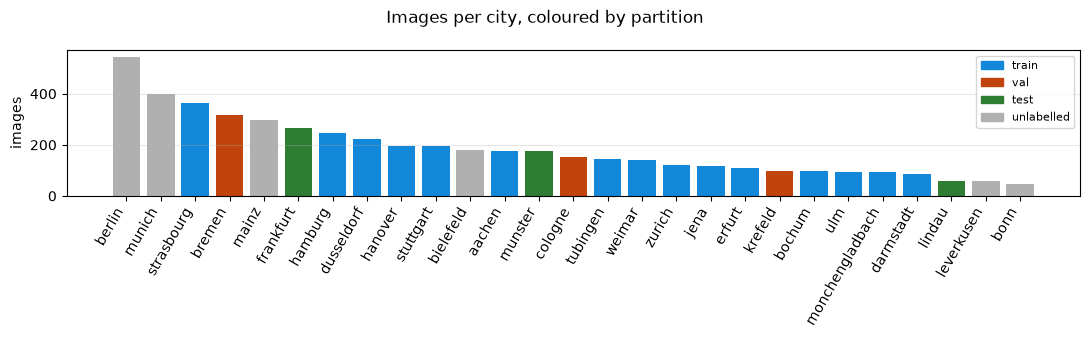

In [4]:
per_city = Counter(f.parent.name for f in frames)
order = sorted(per_city, key=per_city.get, reverse=True)
colour = {"train": COLOURS[0], "val": COLOURS[2], "test": COLOURS[3], "unlabelled": "#b0b0b0"}
belongs = {city: name for name, cities in split["cities"].items() for city in cities}

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(order, [per_city[c] for c in order], color=[colour[belongs.get(c, "unlabelled")] for c in order])
ax.set_ylabel("images")
ax.tick_params(axis="x", rotation=60)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.grid(axis="y", alpha=0.3)
handles = [plt.Rectangle((0, 0), 1, 1, color=colour[k]) for k in colour]
ax.legend(handles, colour, fontsize=8)
fig.suptitle("Images per city, coloured by partition")
save(fig, eda_dir / "cities", close=False)

withheld = sum(per_city[c] for c in per_city if c not in belongs)
print(f"{withheld} images in {sum(1 for c in per_city if c not in belongs)} cities carry no public labels")

City sizes range from 85 to 365 images, so holding out whole cities makes the partitions approximate rather than exact. Worth it: a frame-level split would put neighbouring frames of one street on both sides and inflate every score.

## Label taxonomy

Nineteen of the 34 labelIds are evaluated; the rest map to the ignore index. The mapping is read from the official definitions, so it cannot drift from the benchmark.

In [5]:
lookup = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for label in labels:
    if 0 <= label.trainId < NUM_CLASSES:
        lookup[label.id] = label.trainId

evaluated = {int(lookup[i]): i for i in range(256) if lookup[i] != IGNORE_INDEX}
ignored = [l for l in labels if l.id >= 0 and l.trainId not in range(NUM_CLASSES)]

print("evaluated")
for train_id in range(NUM_CLASSES):
    print(f"  trainId {train_id:>2}  labelId {evaluated[train_id]:>2}  {CLASS_NAMES[train_id]}")
print(f"\nignored ({len(ignored)}): {', '.join(l.name for l in ignored)}")

evaluated
  trainId  0  labelId  7  road
  trainId  1  labelId  8  sidewalk
  trainId  2  labelId 11  building
  trainId  3  labelId 12  wall
  trainId  4  labelId 13  fence
  trainId  5  labelId 17  pole
  trainId  6  labelId 19  traffic light
  trainId  7  labelId 20  traffic sign
  trainId  8  labelId 21  vegetation
  trainId  9  labelId 22  terrain
  trainId 10  labelId 23  sky
  trainId 11  labelId 24  person
  trainId 12  labelId 25  rider
  trainId 13  labelId 26  car
  trainId 14  labelId 27  truck
  trainId 15  labelId 28  bus
  trainId 16  labelId 31  train
  trainId 17  labelId 32  motorcycle
  trainId 18  labelId 33  bicycle

ignored (15): unlabeled, ego vehicle, rectification border, out of roi, static, dynamic, ground, parking, rail track, guard rail, bridge, tunnel, polegroup, caravan, trailer


Several ignored labels look like evaluated ones: `parking` and `rail track` beside `road`, `guard rail` beside `fence`, `polegroup` beside `pole`, `caravan` and `trailer` beside `car`. The error analysis should expect penalised predictions that look reasonable.

## Class imbalance

One pass over every training label map, not a sample.

In [6]:
train_masks = [m for m in masks if m.parts[-3] == "train" and m.parent.name in split["cities"]["train"]]
crop_h, crop_w = config["input"]["crop"]

pixels = np.zeros(NUM_CLASSES + 1, dtype=np.int64)
images_with = Counter()
share_when_present = {index: [] for index in range(NUM_CLASSES)}
void_pixels = Counter()
crop_has = Counter()

for path in train_masks:
    raw = np.array(Image.open(path))
    mask = lookup[raw]
    counts = np.bincount(np.where(mask == IGNORE_INDEX, NUM_CLASSES, mask).ravel(), minlength=NUM_CLASSES + 1)
    pixels += counts
    frame = mask.size
    for index in np.nonzero(counts[:NUM_CLASSES])[0]:
        images_with[int(index)] += 1
        share_when_present[int(index)].append(counts[index] / frame)
    for label_id in np.unique(raw[mask == IGNORE_INDEX]):
        void_pixels[int(label_id)] += int((raw == label_id).sum())

    top = rng.integers(0, mask.shape[0] - crop_h + 1)
    left = rng.integers(0, mask.shape[1] - crop_w + 1)
    crop_has.update(int(i) for i in np.unique(mask[top:top + crop_h, left:left + crop_w]) if i != IGNORE_INDEX)

evaluated_total = int(pixels[:NUM_CLASSES].sum())
print(f"{len(train_masks)} training label maps, {pixels.sum() / 1e9:.1f} billion pixels")
print(f"ignored: {(pixels.sum() - evaluated_total) / pixels.sum():.1%} of every frame")

2406 training label maps, 5.0 billion pixels
ignored: 11.8% of every frame


In [7]:
shares = {name: int(pixels[i]) / evaluated_total for i, name in enumerate(CLASS_NAMES)}
presence = {name: images_with[i] / len(train_masks) for i, name in enumerate(CLASS_NAMES)}
median_area = {name: float(np.median(share_when_present[i])) if share_when_present[i] else 0.0 for i, name in enumerate(CLASS_NAMES)}
crop_presence = {name: crop_has[i] / len(train_masks) for i, name in enumerate(CLASS_NAMES)}

print(f"{'class':<14}{'pixels':>9}{'in images':>11}{'area when present':>19}{'in a 512 crop':>15}")
for name in sorted(shares, key=shares.get, reverse=True):
    print(f"{name:<14}{shares[name] * 100:>8.3f}%{presence[name] * 100:>10.0f}%{median_area[name] * 100:>18.3f}%{crop_presence[name] * 100:>14.0f}%")

class            pixels  in images  area when present  in a 512 crop
road            36.799%        98%            33.562%            93%
building        22.915%        99%            20.162%            82%
vegetation      16.071%        97%            13.148%            71%
car              6.784%        95%             4.179%            71%
sidewalk         6.160%        94%             4.665%            79%
sky              3.880%        90%             2.966%            25%
person           1.319%        79%             0.517%            46%
pole             1.173%        99%             0.828%            77%
terrain          1.119%        55%             0.600%            30%
fence            0.921%        43%             0.809%            19%
wall             0.741%        36%             0.685%            17%
traffic sign     0.559%        94%             0.307%            47%
bicycle          0.385%        54%             0.231%            26%
truck            0.309%        12%

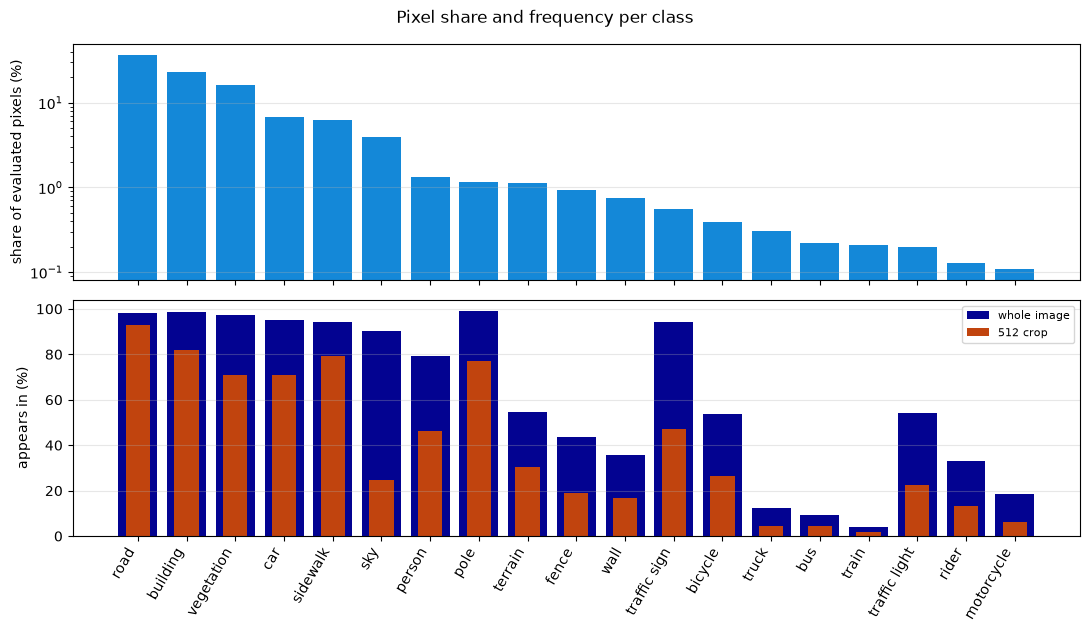

In [8]:
order = sorted(shares, key=shares.get, reverse=True)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
axes[0].bar(order, [shares[n] * 100 for n in order], color=COLOURS[0])
axes[0].set_yscale("log")
axes[0].set_ylabel("share of evaluated pixels (%)")
axes[1].bar(order, [presence[n] * 100 for n in order], color=COLOURS[1], label="whole image")
axes[1].bar(order, [crop_presence[n] * 100 for n in order], color=COLOURS[2], width=0.5, label="512 crop")
axes[1].set_ylabel("appears in (%)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=60)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment("right")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Pixel share and frequency per class")
save(fig, eda_dir / "class_distribution", close=False)

Road, building and vegetation hold $75.8\%$ of evaluated pixels, so predicting only those three already scores about $0.76$ pixel accuracy. Mean intersection over union averages across classes and will not hide the other sixteen, which is why it decides comparisons and pixel accuracy does not.

Rarity has two shapes. Poles hold $1.17\%$ of pixels but appear in $99\%$ of images, traffic signs $0.56\%$ in $94\%$: thin structures lost to boundary imprecision, not to scarcity. Trains hold $0.21\%$ in $4\%$ of images and buses $0.22\%$ in $9\%$, yet cover $0.91\%$ and $0.66\%$ of a frame when visible: large but rarely seen. One remedy will not fix both.

Cropping sharpens the second shape. A $512 \times 512$ window covers an eighth of the frame, so trains fall to $2\%$ of crops and buses to $4\%$. Sky is the clearest case, $90\%$ of images but $25\%$ of crops, because it sits in a band at the top. Cropping reshapes the class prior spatially, not only by area.

## Where the ignored pixels come from

In [9]:
total = int(pixels.sum())
by_name = {l.name: void_pixels[l.id] for l in labels if l.id in void_pixels}
for name in sorted(by_name, key=by_name.get, reverse=True)[:8]:
    print(f"  {name:<22}{by_name[name] / total * 100:>7.2f}% of all pixels")

  ego vehicle              4.67% of all pixels
  out of roi               1.51% of all pixels
  rectification border     1.47% of all pixels
  static                   1.30% of all pixels
  ground                   1.28% of all pixels
  parking                  0.62% of all pixels
  dynamic                  0.29% of all pixels
  bridge                   0.27% of all pixels


The ignore label is not noise. The ego vehicle alone covers $4.67\%$ of every frame, and with the rectification border and out-of-roi region some $7.7\%$ is unusable regardless of content. The loss carries `ignore_index=255`; without it the model learns a twentieth phantom class.

## Normalization statistics

Training partition only. Images are read at a quarter resolution: the channel means shift by under $2 \times 10^{-4}$, while the standard deviations come out about $1\%$ low because averaging neighbouring pixels damps variance.

In [10]:
train_frames = [f for f in frames if f.parts[-3] == "train" and f.parent.name in split["cities"]["train"]]
subset = rng.choice(len(train_frames), size=400, replace=False)

total_sum = np.zeros(3)
total_sq = np.zeros(3)
count = 0
for index in subset:
    image = np.asarray(Image.open(train_frames[index]).reduce(4), dtype=np.float64) / 255.0
    flat = image.reshape(-1, 3)
    total_sum += flat.sum(axis=0)
    total_sq += (flat ** 2).sum(axis=0)
    count += len(flat)

mean = total_sum / count
std = np.sqrt(total_sq / count - mean ** 2)
print(f"mean  {np.round(mean, 4).tolist()}")
print(f"std   {np.round(std, 4).tolist()}")
print(f"over  {len(subset)} training images")

mean  [0.2882, 0.3254, 0.2848]
std   [0.1856, 0.1882, 0.1847]
over  400 training images


## Qualitative samples

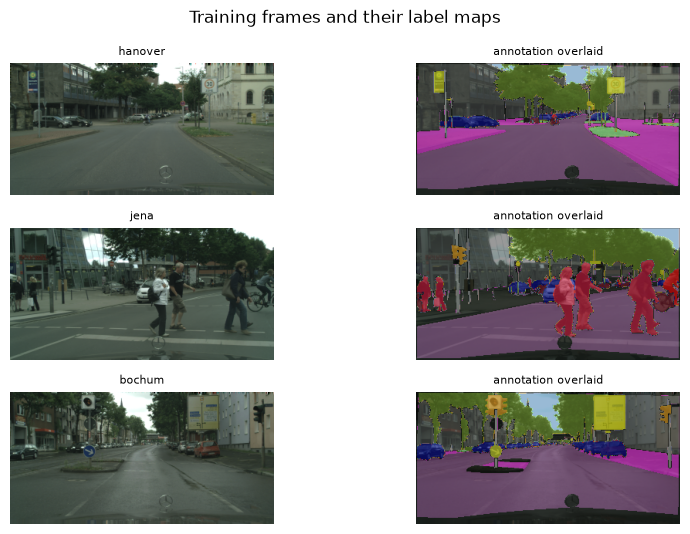

In [11]:
palette = np.zeros((256, 3), dtype=np.uint8)
for label in labels:
    if 0 <= label.trainId < NUM_CLASSES:
        palette[label.trainId] = label.color
palette[IGNORE_INDEX] = (0, 0, 0)

picks = rng.choice(len(train_masks), size=3, replace=False)
fig, axes = plt.subplots(3, 2, figsize=(9, 5.4))
for row, index in enumerate(picks):
    mask_path = train_masks[index]
    frame_path = data_dir / "leftImg8bit" / "train" / mask_path.parent.name / mask_path.name.replace("gtFine_labelIds", "leftImg8bit")
    image = np.asarray(Image.open(frame_path).reduce(6))
    mask = palette[lookup[np.array(Image.open(mask_path).reduce(6))]]
    axes[row, 0].imshow(image)
    axes[row, 1].imshow((0.45 * image + 0.55 * mask).astype(np.uint8))
    axes[row, 0].set_title(mask_path.parent.name, fontsize=8)
    axes[row, 1].set_title("annotation overlaid", fontsize=8)
    for ax in axes[row]:
        ax.axis("off")
fig.suptitle("Training frames and their label maps")
save(fig, eda_dir / "samples", close=False)

Poles and traffic signs are a few pixels wide at full resolution and survive no encoder that downsamples four times. That is the argument for skip connections in the baseline, and for checking the output stride of the pretrained model.

In [12]:
shared_io.write_json(
    eda_dir / "distribution.json",
    {
        "images": len(train_masks),
        "ignored_pixel_share": (total - evaluated_total) / total,
        "normalization": {"mean": mean.tolist(), "std": std.tolist()},
        "per_class_pixel_share": shares,
        "per_class_image_share": presence,
        "per_class_median_area_when_present": median_area,
        "per_class_crop_share": crop_presence,
        "split": {"cities": split["cities"], "counts": split["counts"]},
    },
)

## Consequences for the implementation

Both models share the split, the nineteen classes, the ignore index and the statistics above; mIoU is primary and Dice secondary, reported per class as well as averaged.

The imbalance gives the controlled experiment its hypothesis: if Dice beats cross-entropy it should do so on the scarce classes, not uniformly. The crop measurement gives a second: classes that survive few crops should gain most from a larger crop, which makes resolution the natural second factor.